In [1]:
!pip install tensorflow openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

In [7]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
data_folder   = r"/content"
output_folder = r"/content"

os.makedirs(output_folder, exist_ok=True)

files = glob.glob(os.path.join(data_folder, "RevenueCenter_*.xlsx"))

In [9]:
# Error matrix
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

In [10]:
def create_sequences(series, window=30):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)


Processing: RevenueCenter_5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0613 - val_loss: 0.0194
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0103 - val_loss: 0.0387
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0092 - val_loss: 0.0267
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0095 - val_loss: 0.0180
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0082 - val_loss: 0.0216
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0061 - val_loss: 0.0167
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0069 - val_loss: 0.0165
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0090 - val_loss: 0.0164
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0059 - val_loss: 0.0283
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0077 - val_loss: 0.0180
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0060 - val_loss: 0.0168
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

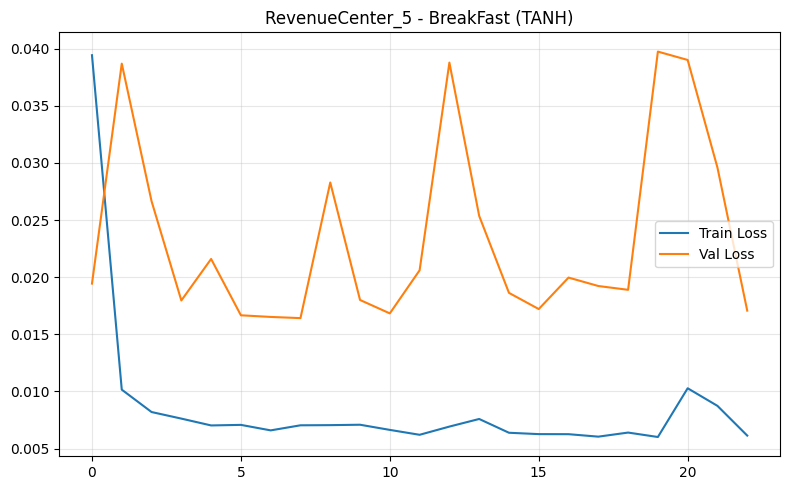

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


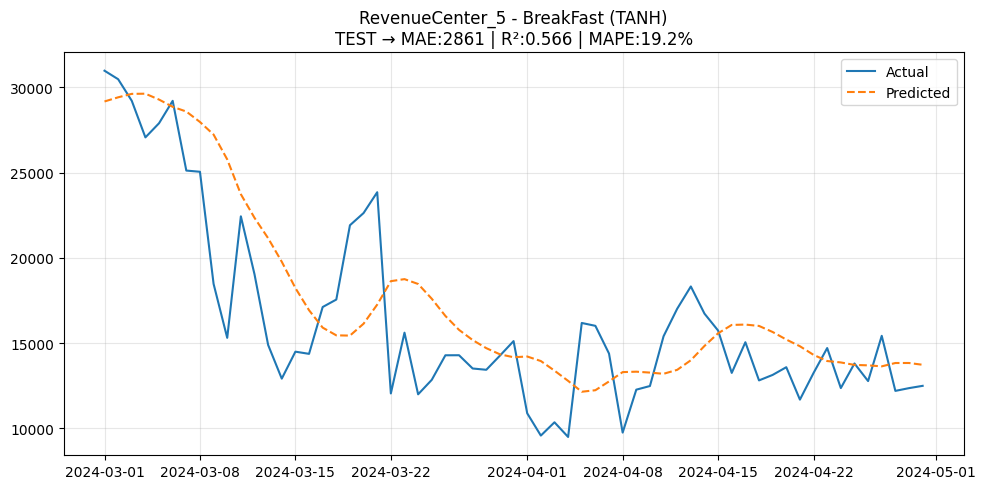

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0244 - val_loss: 0.0172
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0114 - val_loss: 0.0173
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0167 - val_loss: 0.0176
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0132 - val_loss: 0.0158
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0141 - val_loss: 0.0161
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0151 - val_loss: 0.0160
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0126 - val_loss: 0.0160
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0163 - val_loss: 0.0171
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0136 - val_loss: 0.0172
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0121 - val_loss: 0.0160
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0120 - val_loss: 0.0168
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

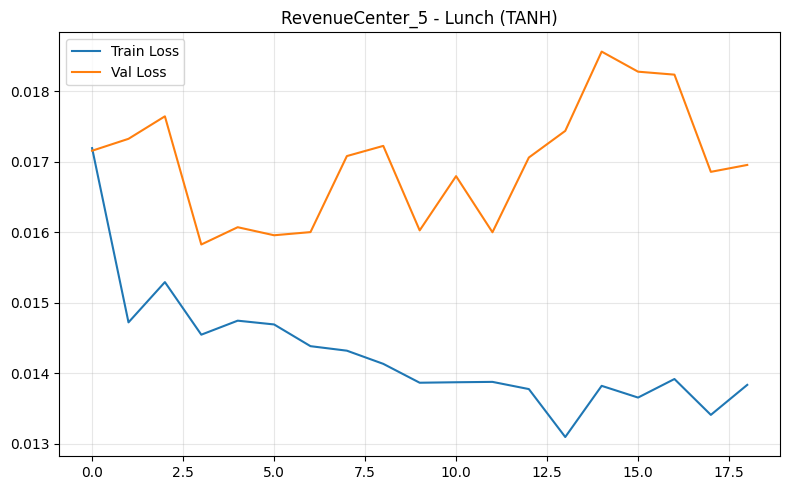

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


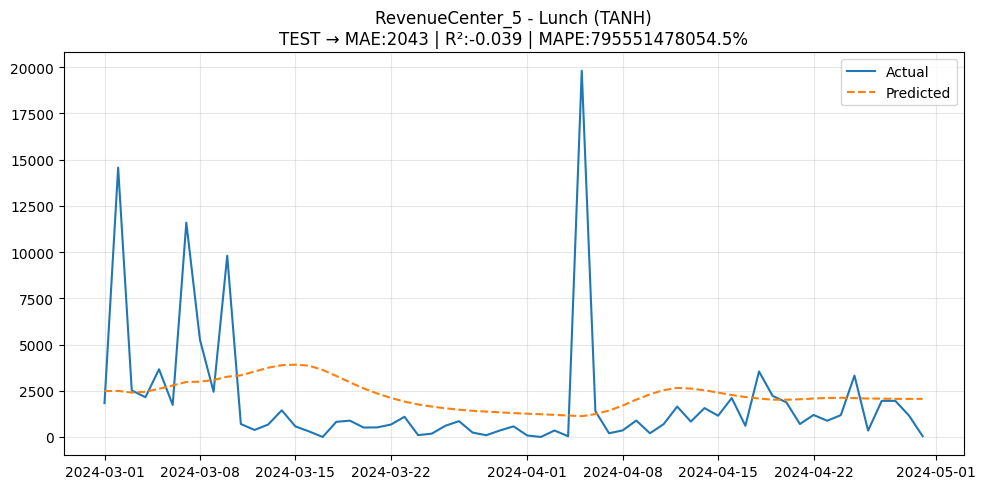

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0238 - val_loss: 0.0574
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0182 - val_loss: 0.0588
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0184 - val_loss: 0.0606
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0173 - val_loss: 0.0625
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0267 - val_loss: 0.0652
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0246 - val_loss: 0.0632
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0187 - val_loss: 0.0675
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0202 - val_loss: 0.0677
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0209 - val_loss: 0.0817
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0200 - val_loss: 0.0811
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0180 - val_loss: 0.0812
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

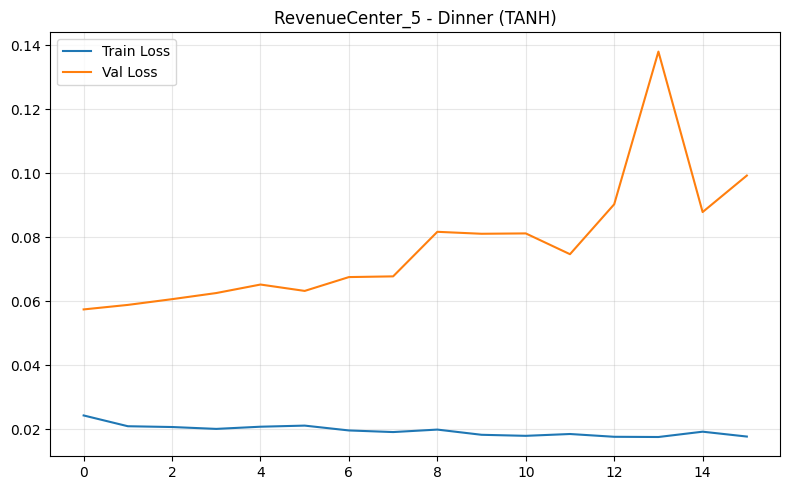

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


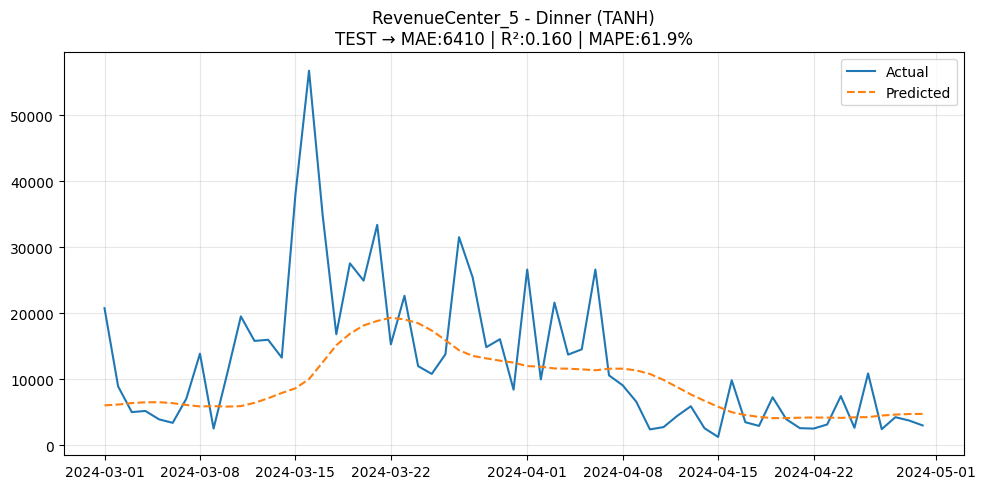

Saved: /content/RevenueCenter_5

Processing: RevenueCenter_7


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0097 - val_loss: 0.0047
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0079 - val_loss: 0.0046
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0081 - val_loss: 0.0052
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0092 - val_loss: 0.0045
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0080 - val_loss: 0.0045
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0080 - val_loss: 0.0045
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0111 - val_loss: 0.0045
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0101 - val_loss: 0.0043
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0084 - val_loss: 0.0045
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0070 - val_loss: 0.0044
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0108 - val_loss: 0.0044
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

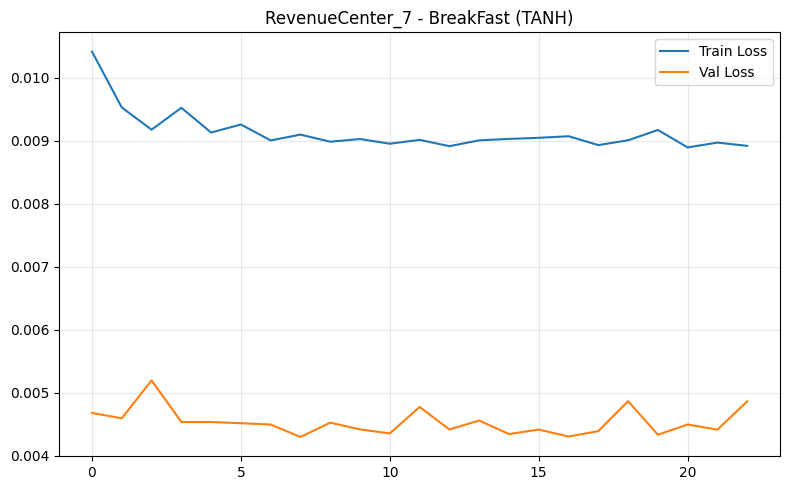

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


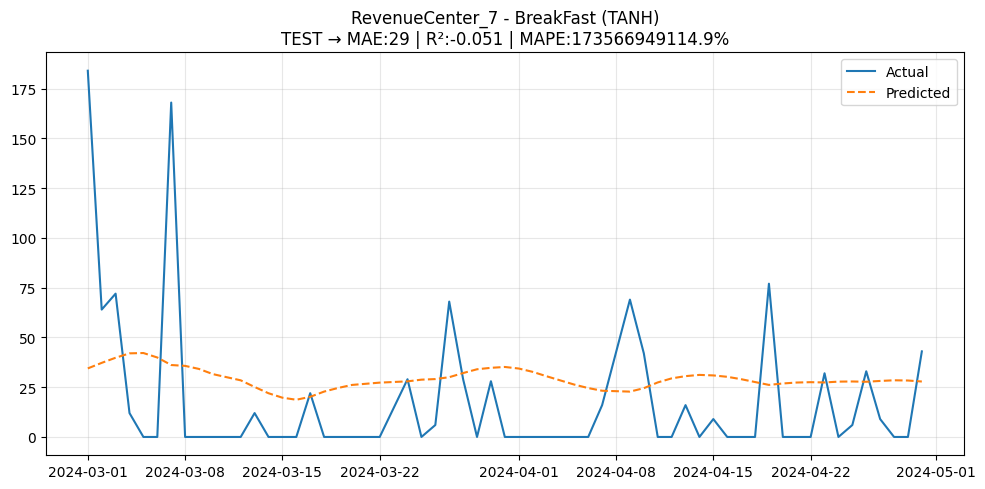

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0143 - val_loss: 0.0418
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0116 - val_loss: 0.0415
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0091 - val_loss: 0.0404
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0098 - val_loss: 0.0385
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0124 - val_loss: 0.0423
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0102 - val_loss: 0.0414
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0095 - val_loss: 0.0395
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0123 - val_loss: 0.0416
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0111 - val_loss: 0.0401
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0102 - val_loss: 0.0402
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0119 - val_loss: 0.0403
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

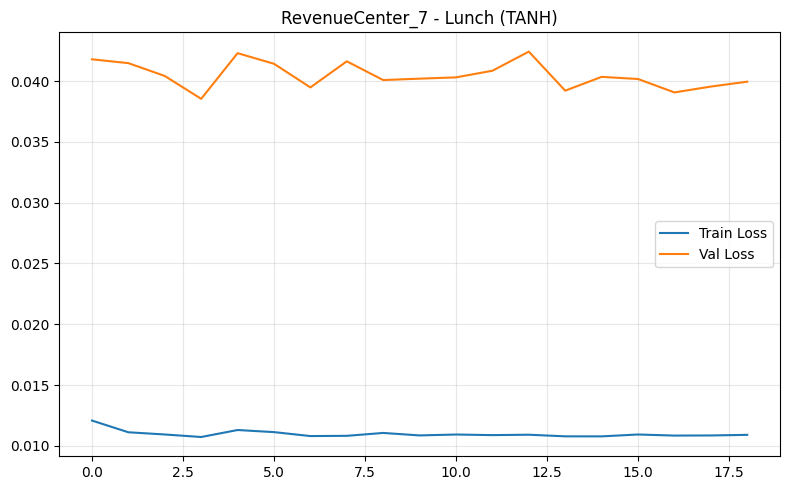

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


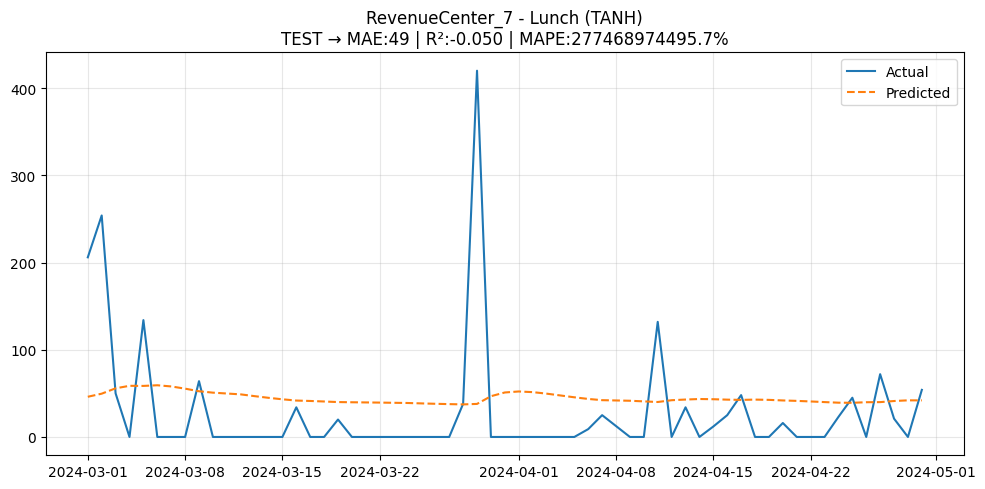

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0310 - val_loss: 0.0736
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0187 - val_loss: 0.0737
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0209 - val_loss: 0.0902
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0154 - val_loss: 0.0780
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0196 - val_loss: 0.0938
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0206 - val_loss: 0.0812
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0199 - val_loss: 0.0806
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0168 - val_loss: 0.0865
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0145 - val_loss: 0.0783
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0170 - val_loss: 0.0855
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0213 - val_loss: 0.0848
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

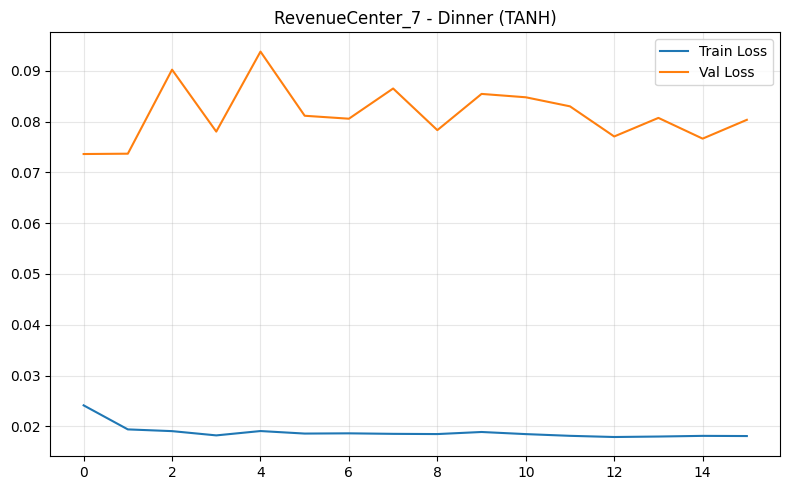

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


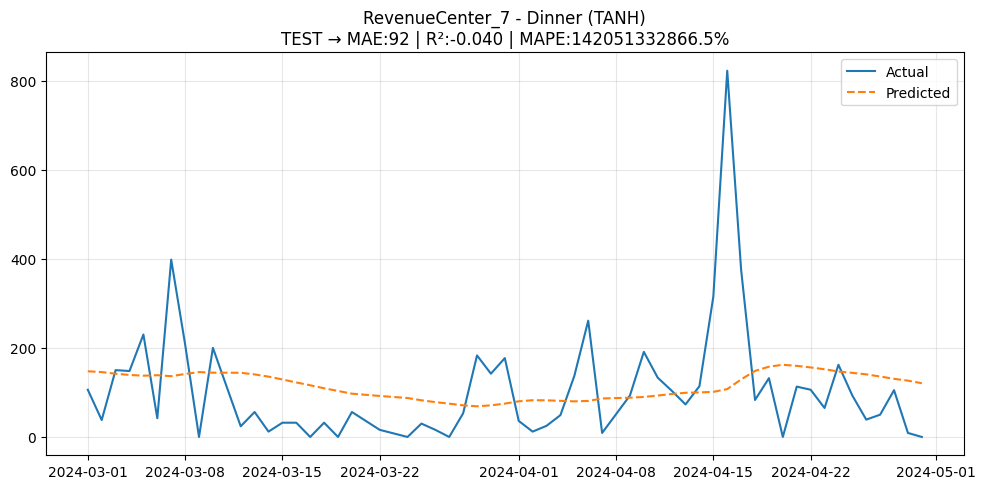

Saved: /content/RevenueCenter_7

Processing: RevenueCenter_2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0229 - val_loss: 0.0203
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0191 - val_loss: 0.0302
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0151 - val_loss: 0.0242
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0142 - val_loss: 0.0283
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0152 - val_loss: 0.0231
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0162 - val_loss: 0.0235
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0164 - val_loss: 0.0304
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0208 - val_loss: 0.0277
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0181 - val_loss: 0.0235
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0176 - val_loss: 0.0293
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0173 - val_loss: 0.0238
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

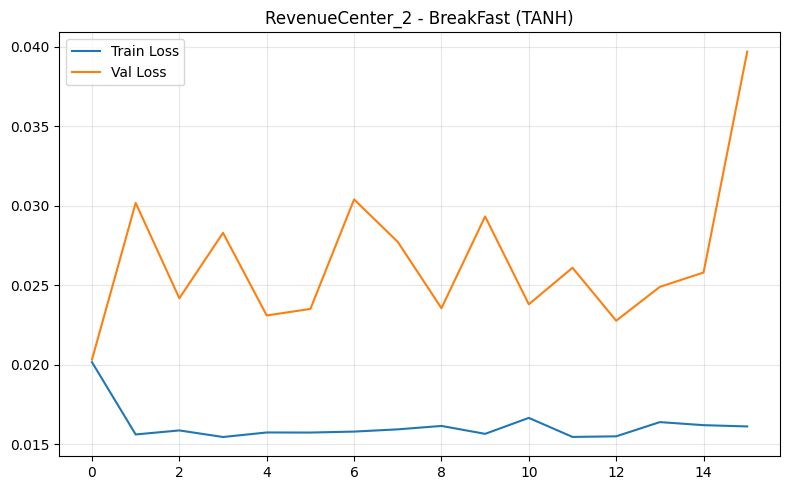

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


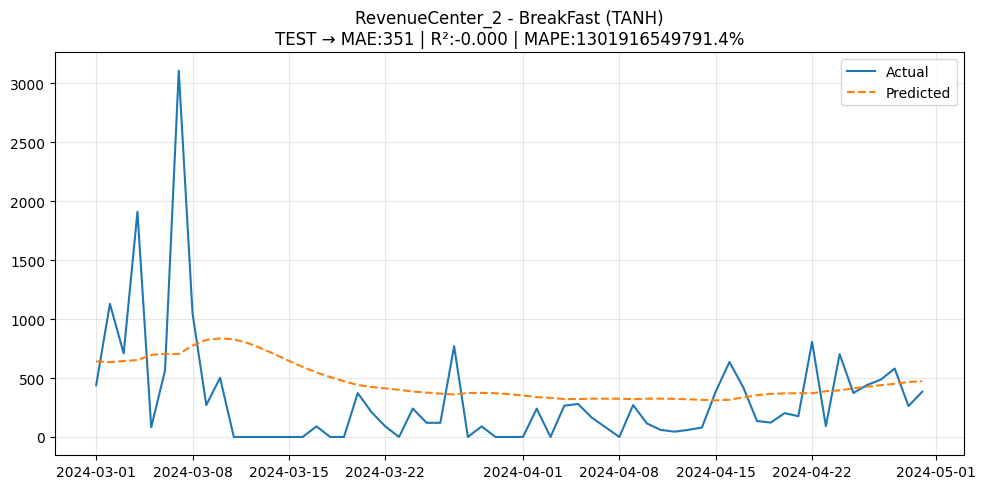

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0309 - val_loss: 0.0523
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0141 - val_loss: 0.0549
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0133 - val_loss: 0.0553
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0182 - val_loss: 0.0616
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0157 - val_loss: 0.0586
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0175 - val_loss: 0.0547
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0165 - val_loss: 0.0680
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0195 - val_loss: 0.0638
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0166 - val_loss: 0.0621
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0169 - val_loss: 0.0590
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0237 - val_loss: 0.0713
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

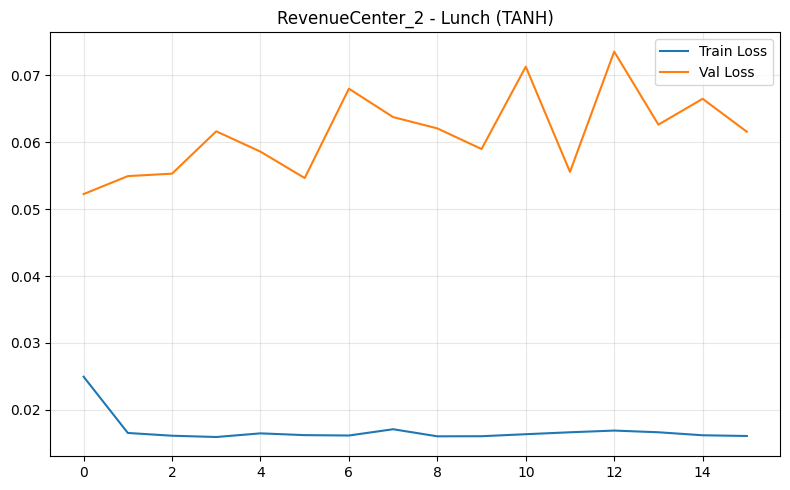

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


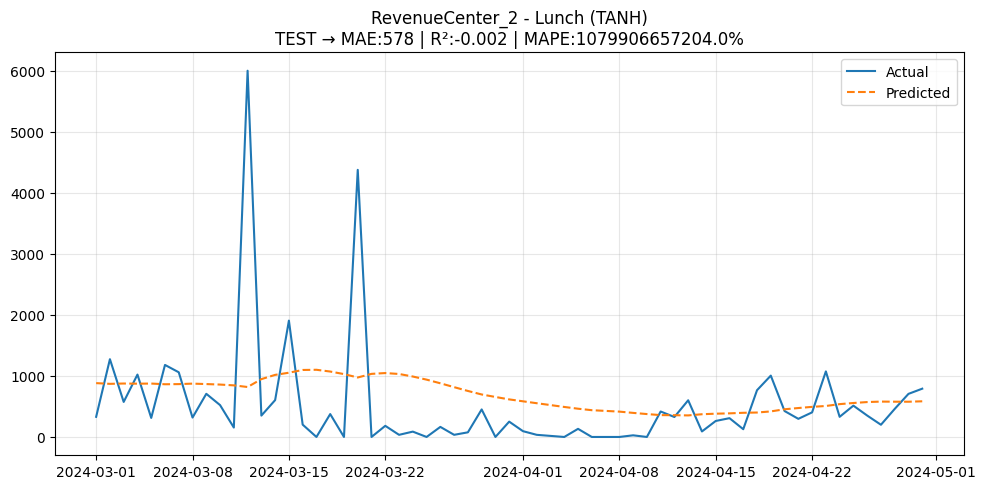

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0021 - val_loss: 0.0260
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0022 - val_loss: 0.0282
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0018 - val_loss: 0.0307
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0017 - val_loss: 0.0285
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0020 - val_loss: 0.0295
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0018 - val_loss: 0.0293
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0020 - val_loss: 0.0270
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0018 - val_loss: 0.0289
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0022 - val_loss: 0.0290
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0015 - val_loss: 0.0277
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0018 - val_loss: 0.0283
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

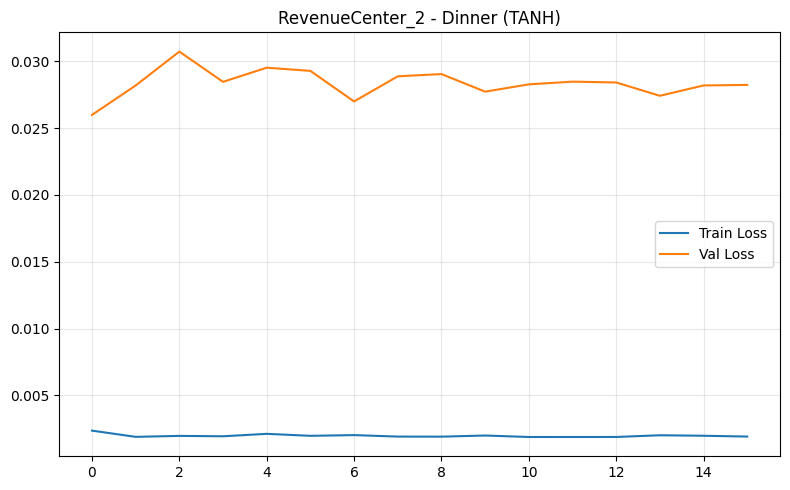

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


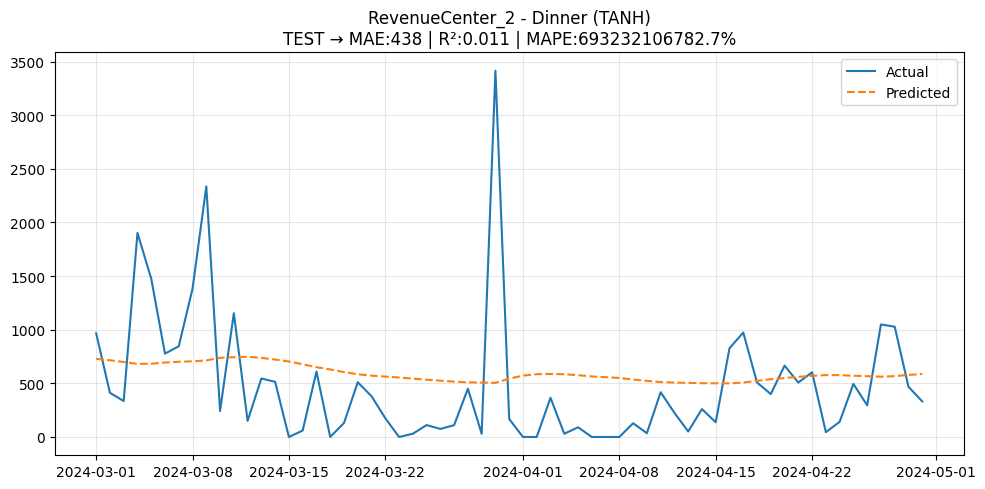

Saved: /content/RevenueCenter_2

Processing: RevenueCenter_1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0072 - val_loss: 0.0367
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0051 - val_loss: 0.0362
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0053 - val_loss: 0.0297
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0046 - val_loss: 0.0276
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0053 - val_loss: 0.0281
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0046 - val_loss: 0.0285
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0036 - val_loss: 0.0285
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0043 - val_loss: 0.0287
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0058 - val_loss: 0.0299
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0042 - val_loss: 0.0293
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0044 - val_loss: 0.0293
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

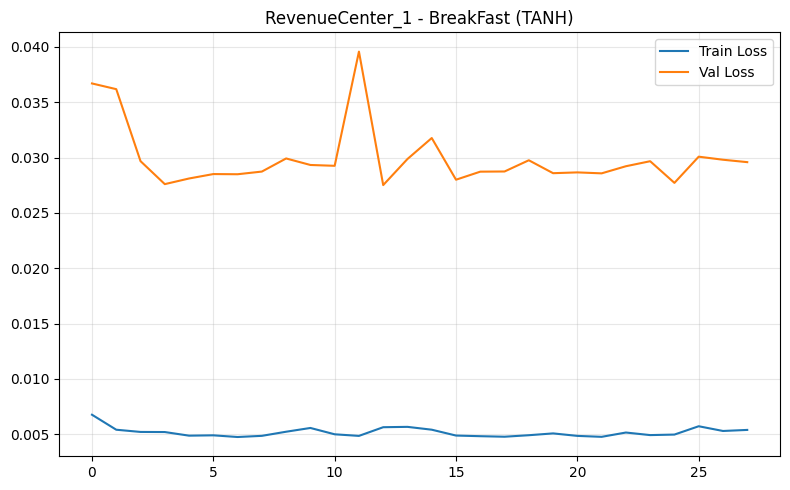

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


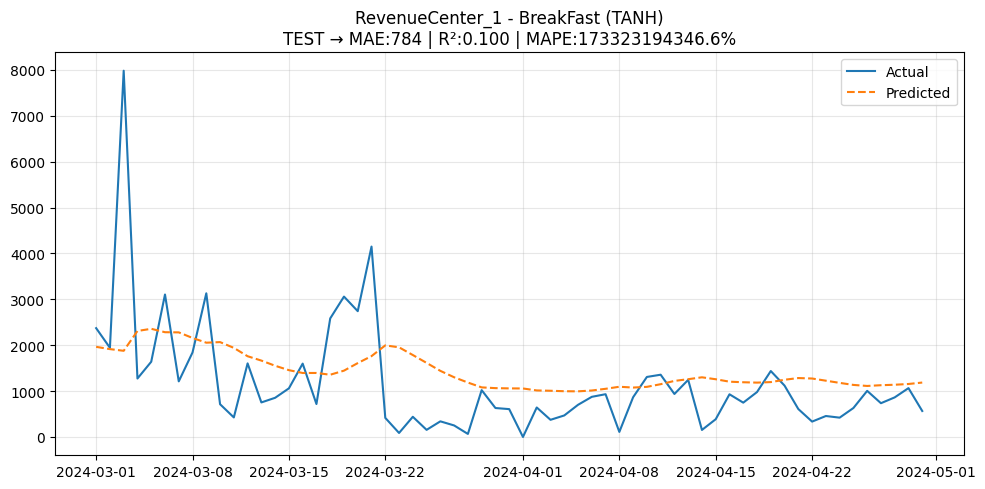

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0189 - val_loss: 0.0813
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0100 - val_loss: 0.0742
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0123 - val_loss: 0.0765
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0111 - val_loss: 0.0782
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0121 - val_loss: 0.0722
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0133 - val_loss: 0.0647
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0141 - val_loss: 0.0687
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0105 - val_loss: 0.0688
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0114 - val_loss: 0.0672
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0127 - val_loss: 0.0801
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0088 - val_loss: 0.0608
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

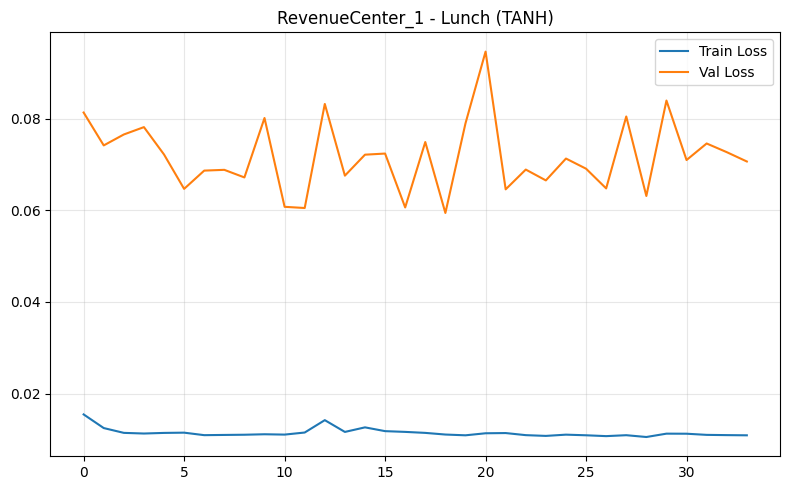

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


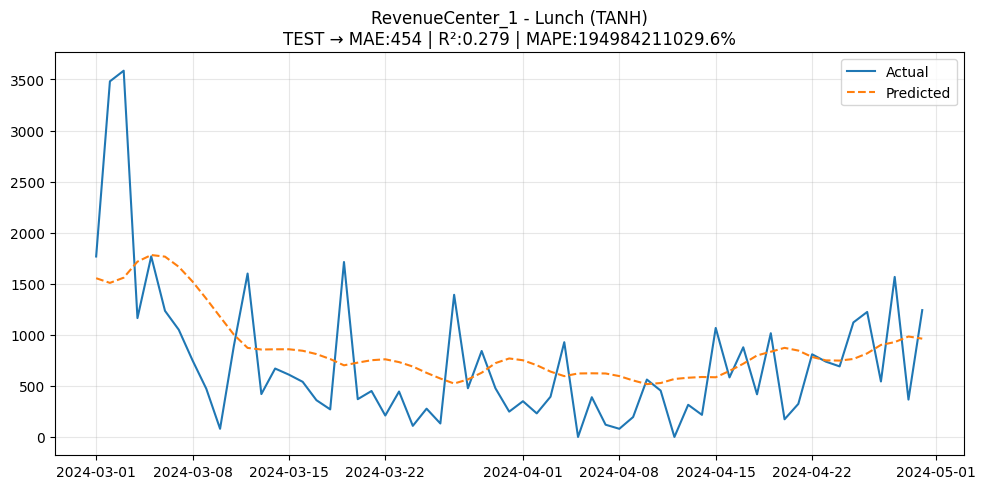

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0369 - val_loss: 0.0267
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0151 - val_loss: 0.0313
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0136 - val_loss: 0.0252
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0132 - val_loss: 0.0459
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0129 - val_loss: 0.0335
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0114 - val_loss: 0.0257
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0155 - val_loss: 0.0407
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0103 - val_loss: 0.0279
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0134 - val_loss: 0.0461
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0137 - val_loss: 0.0292
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0112 - val_loss: 0.0314
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

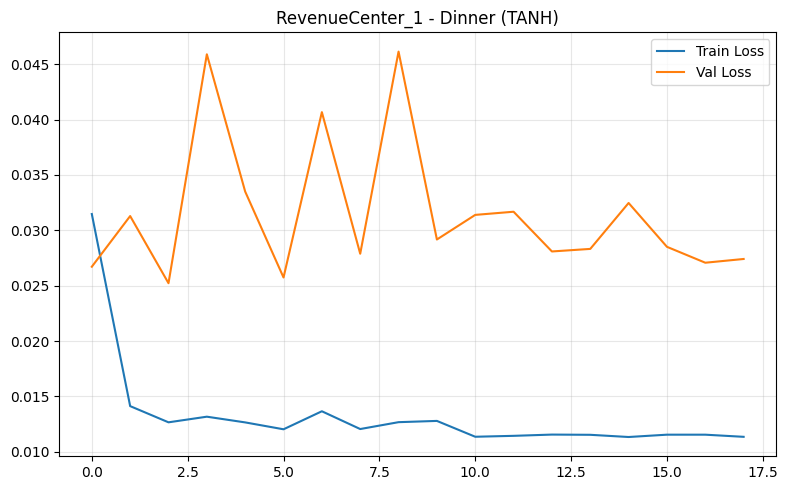

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


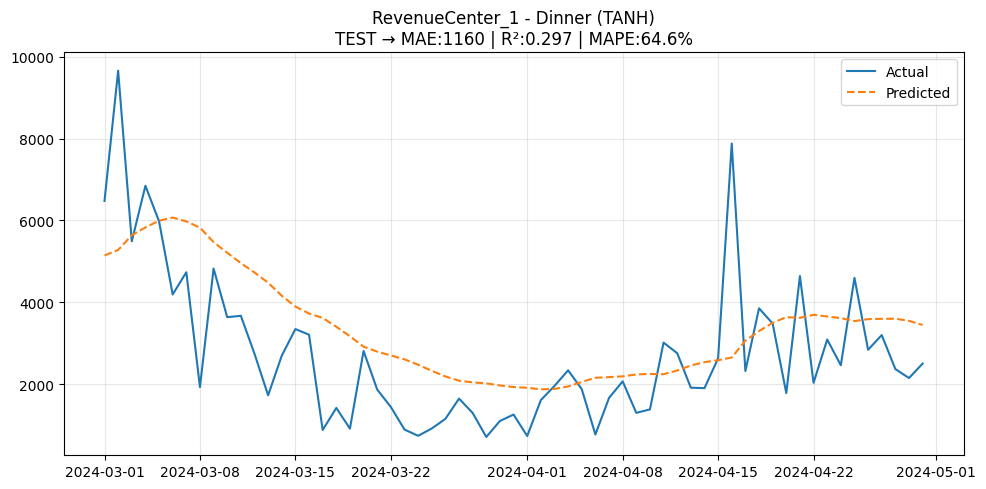

Saved: /content/RevenueCenter_1

Processing: RevenueCenter_6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0215 - val_loss: 0.0503
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0211 - val_loss: 0.0498
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0277 - val_loss: 0.0519
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0214 - val_loss: 0.0513
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0294 - val_loss: 0.0525
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0179 - val_loss: 0.0524
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0239 - val_loss: 0.0507
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0198 - val_loss: 0.0519
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0226 - val_loss: 0.0505
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0236 - val_loss: 0.0501
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0235 - val_loss: 0.0500
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

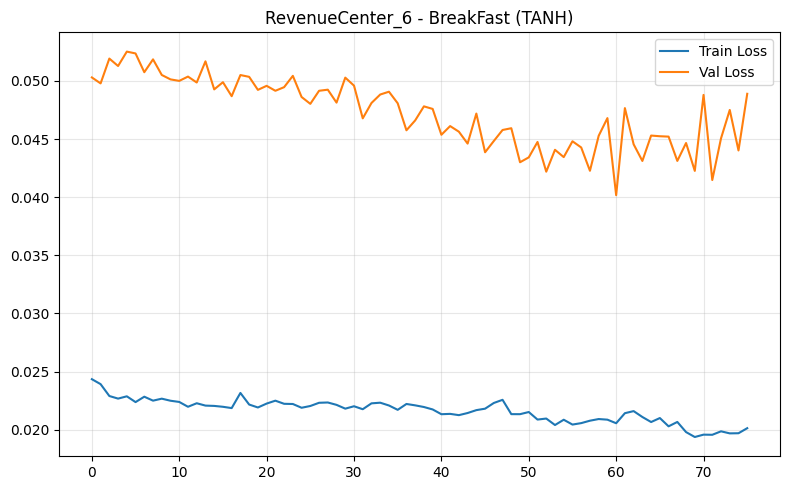

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


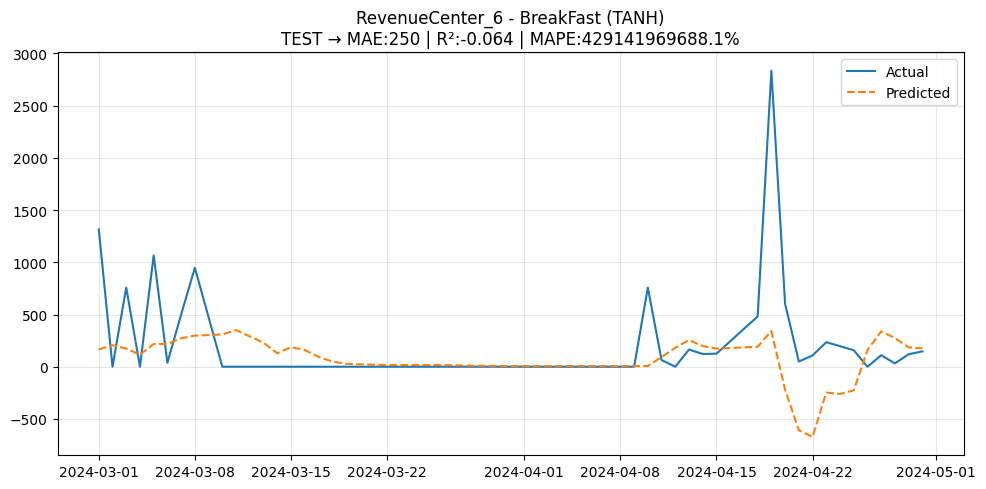

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0146 - val_loss: 0.0191
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0097 - val_loss: 0.0193
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0092 - val_loss: 0.0194
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0090 - val_loss: 0.0195
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0083 - val_loss: 0.0201
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0092 - val_loss: 0.0206
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0091 - val_loss: 0.0195
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0108 - val_loss: 0.0194
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0089 - val_loss: 0.0196
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0114 - val_loss: 0.0207
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0085 - val_loss: 0.0192
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

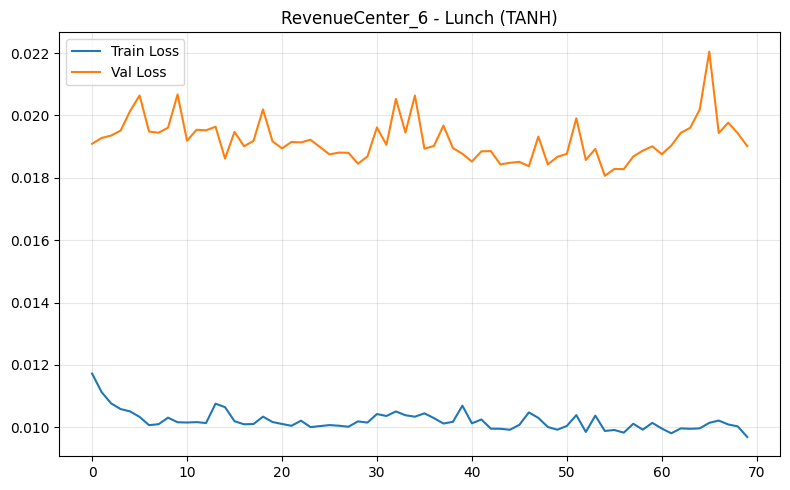

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


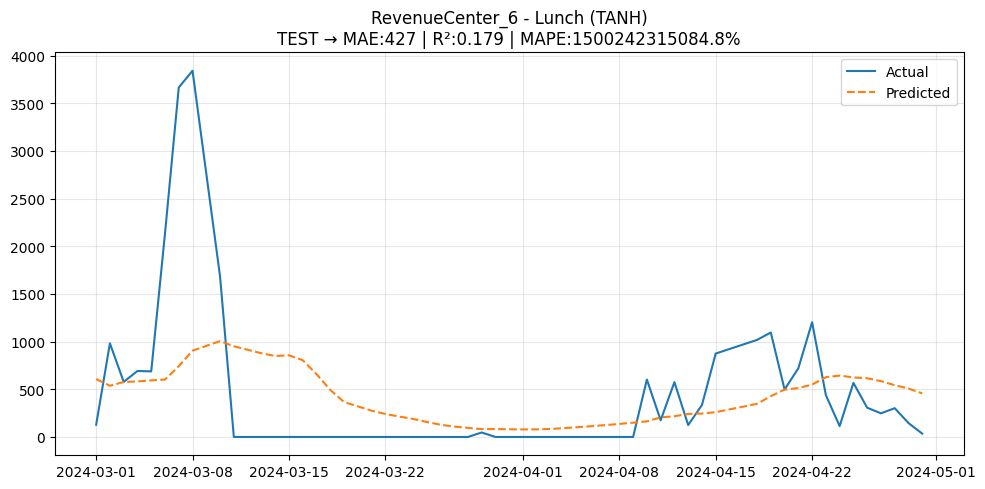

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0015 - val_loss: 0.0244
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0018 - val_loss: 0.0246
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0015 - val_loss: 0.0247
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0010 - val_loss: 0.0245
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0032 - val_loss: 0.0251
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0024 - val_loss: 0.0246
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0045 - val_loss: 0.0251
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0010 - val_loss: 0.0248
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0028 - val_loss: 0.0251
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0026 - val_loss: 0.0258
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0051 - val_loss: 0.0250
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

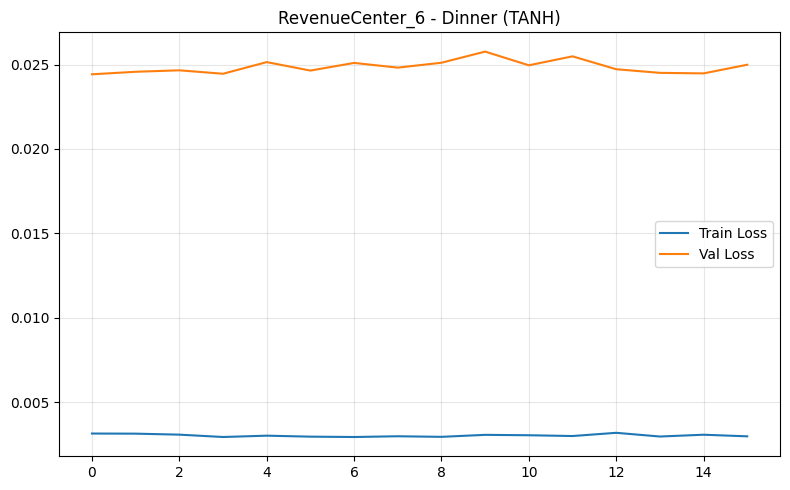

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


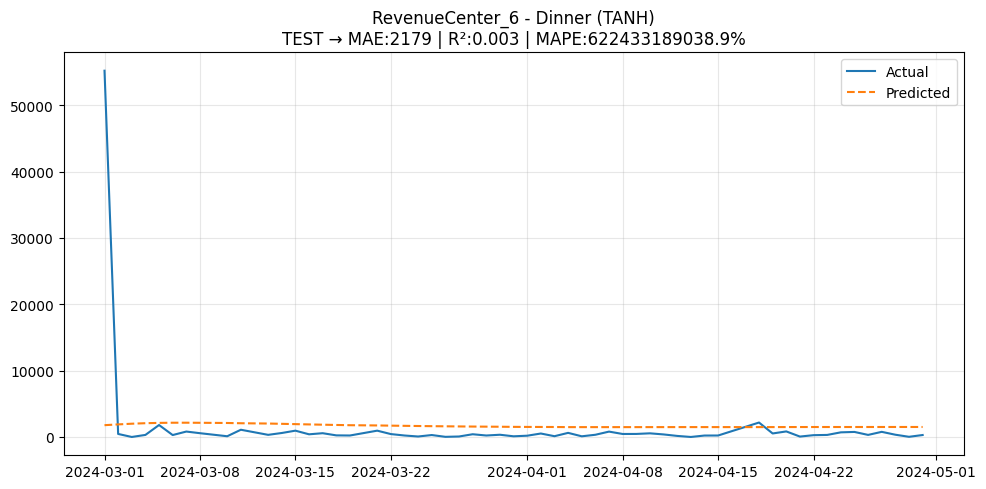

Saved: /content/RevenueCenter_6

Processing: RevenueCenter_4
Skipping RevenueCenter_4 - BreakFast (constant values)
Skipping RevenueCenter_4 - Lunch (constant values)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0081 - val_loss: 1.1494e-05
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0022 - val_loss: 1.2352e-04
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0028 - val_loss: 5.1396e-05
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0042 - val_loss: 3.1924e-05
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 5.0399e-04 - val_loss: 1.6582e-06
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0010 - val_loss: 1.5609e-05
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4.8844e-04 - val_loss: 2.7621e-05
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0042 - val_loss: 2.2780e-05
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 5.0068e-04 - val_loss: 2.4625e-04
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0035 - val_loss: 1.7681e-05
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 7.4604e-04 - val_loss: 6.1

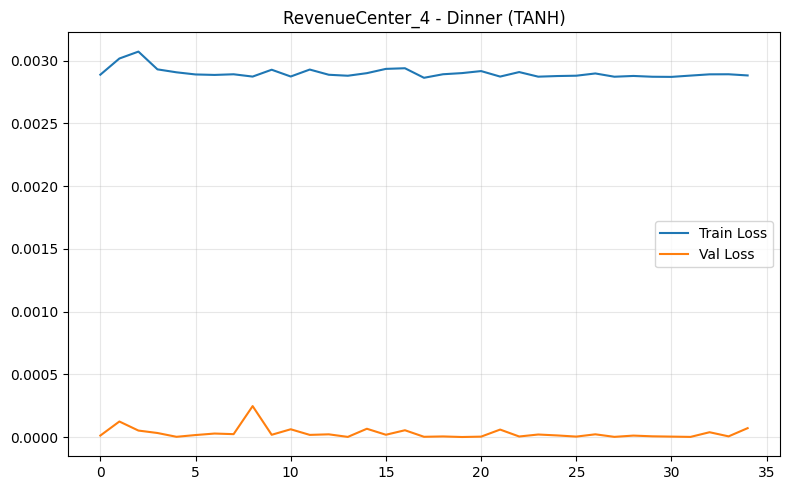

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


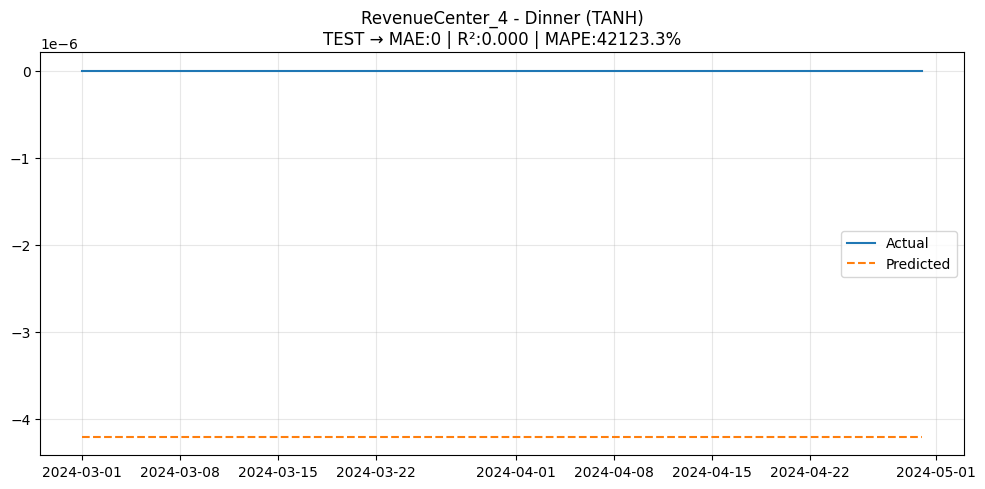

Saved: /content/RevenueCenter_4

Processing: RevenueCenter_8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0067 - val_loss: 0.0026
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0061 - val_loss: 0.0036
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0063 - val_loss: 0.0026
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0057 - val_loss: 0.0026
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0070 - val_loss: 0.0024
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0130 - val_loss: 0.0025
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0065 - val_loss: 0.0023
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0143 - val_loss: 0.0023
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0055 - val_loss: 0.0025
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0078 - val_loss: 0.0023
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0049 - val_loss: 0.0025
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

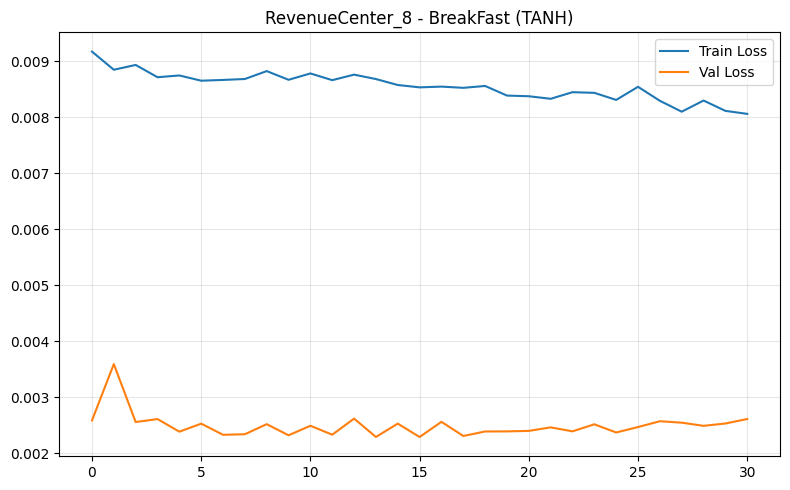

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


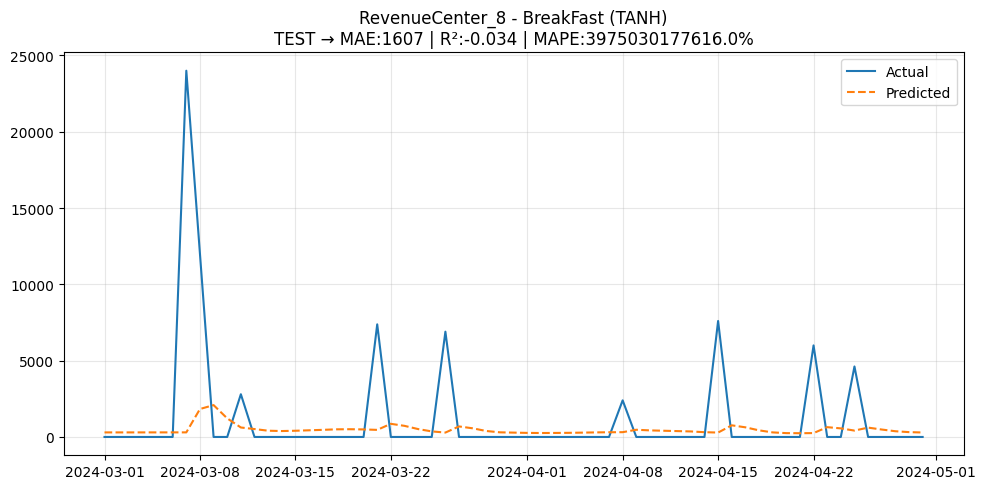

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0161 - val_loss: 0.0985
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0129 - val_loss: 0.0998
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0158 - val_loss: 0.1010
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0158 - val_loss: 0.0998
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0141 - val_loss: 0.1001
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0139 - val_loss: 0.1016
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0119 - val_loss: 0.0959
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0147 - val_loss: 0.1053
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0169 - val_loss: 0.1048
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0136 - val_loss: 0.1003
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0172 - val_loss: 0.1041
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

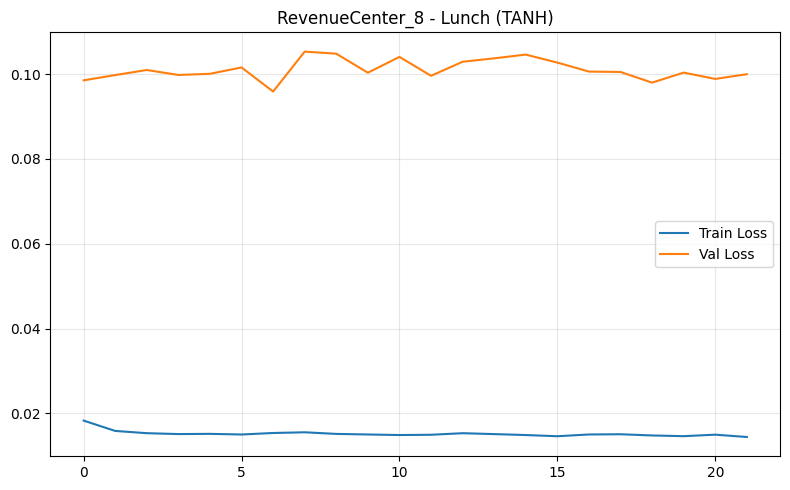

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


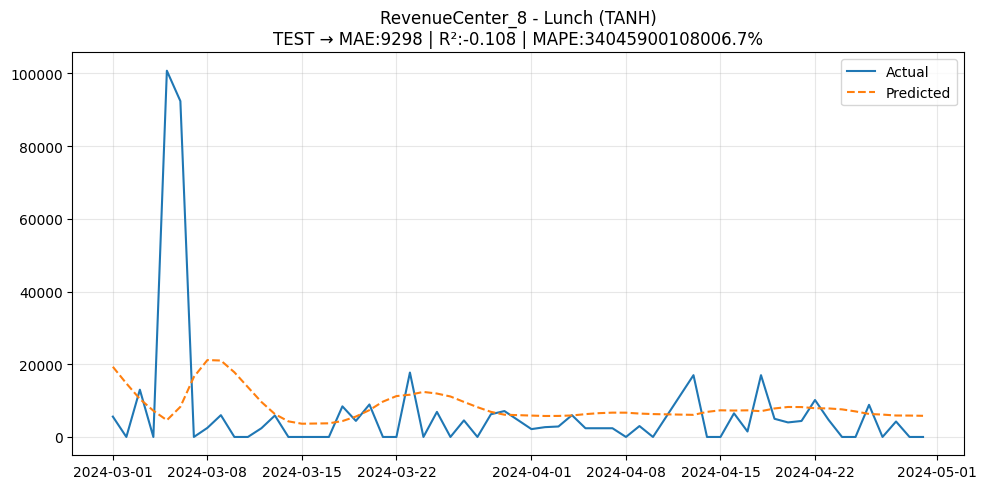

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0170 - val_loss: 0.0546
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0141 - val_loss: 0.0549
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0146 - val_loss: 0.0543
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0118 - val_loss: 0.0553
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0129 - val_loss: 0.0572
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0137 - val_loss: 0.0537
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0141 - val_loss: 0.0543
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0152 - val_loss: 0.0653
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0147 - val_loss: 0.0527
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0114 - val_loss: 0.0560
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0107 - val_loss: 0.0574
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

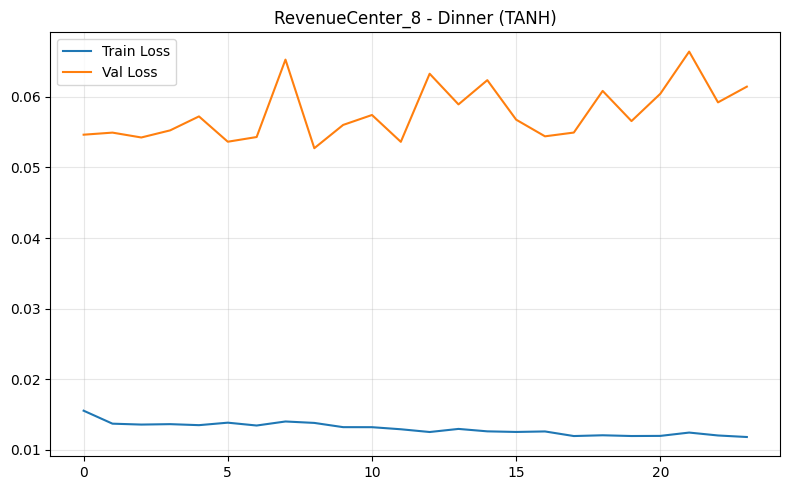

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


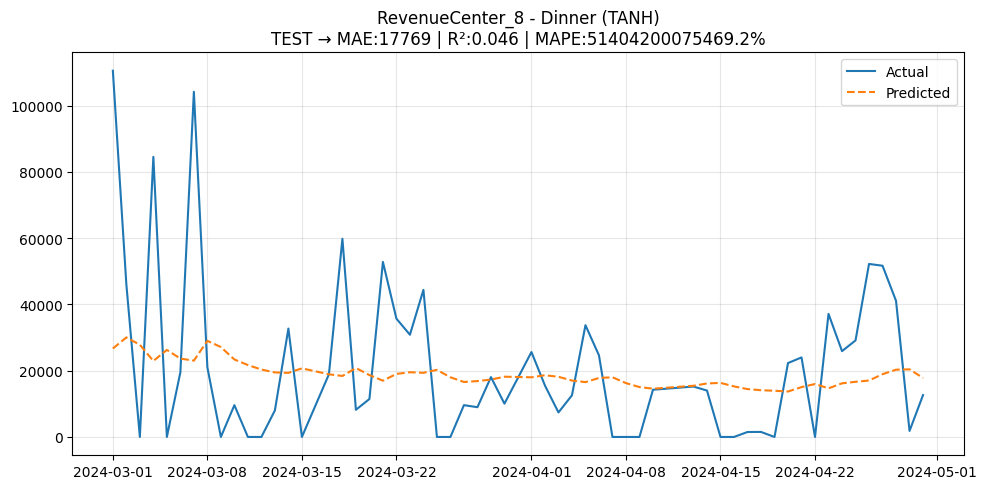

Saved: /content/RevenueCenter_8

Processing: RevenueCenter_3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0352 - val_loss: 0.0359
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0229 - val_loss: 0.0360
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0222 - val_loss: 0.0372
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0246 - val_loss: 0.0366
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0243 - val_loss: 0.0384
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0246 - val_loss: 0.0410
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0262 - val_loss: 0.0368
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0208 - val_loss: 0.0362
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0228 - val_loss: 0.0378
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0208 - val_loss: 0.0402
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0220 - val_loss: 0.0426
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

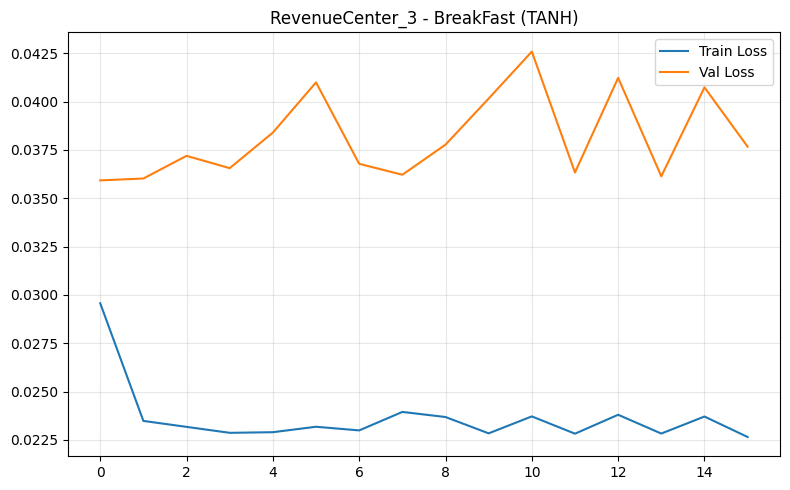

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


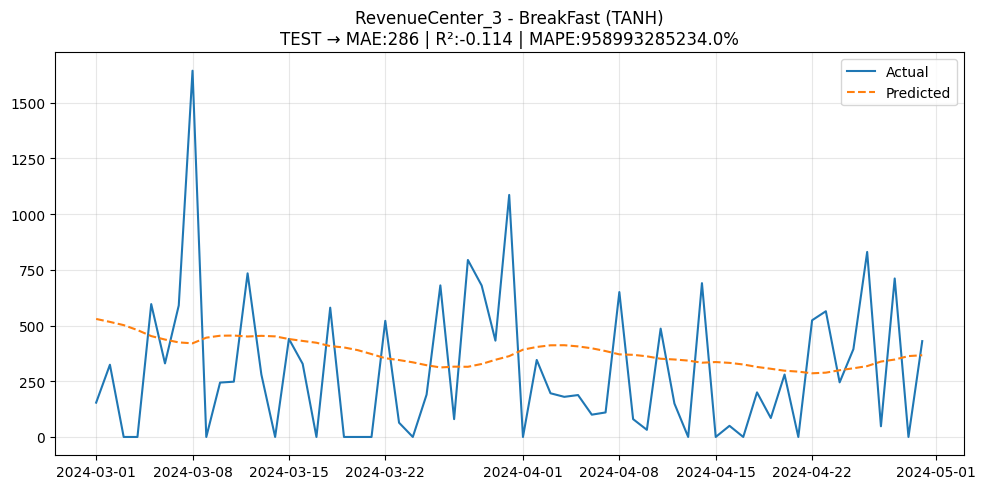

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0201 - val_loss: 0.0598
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0118 - val_loss: 0.0673
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0089 - val_loss: 0.0499
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0100 - val_loss: 0.0506
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0092 - val_loss: 0.0638
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0105 - val_loss: 0.0547
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0106 - val_loss: 0.0638
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0093 - val_loss: 0.0520
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0089 - val_loss: 0.0596
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0095 - val_loss: 0.0569
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0077 - val_loss: 0.0526
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

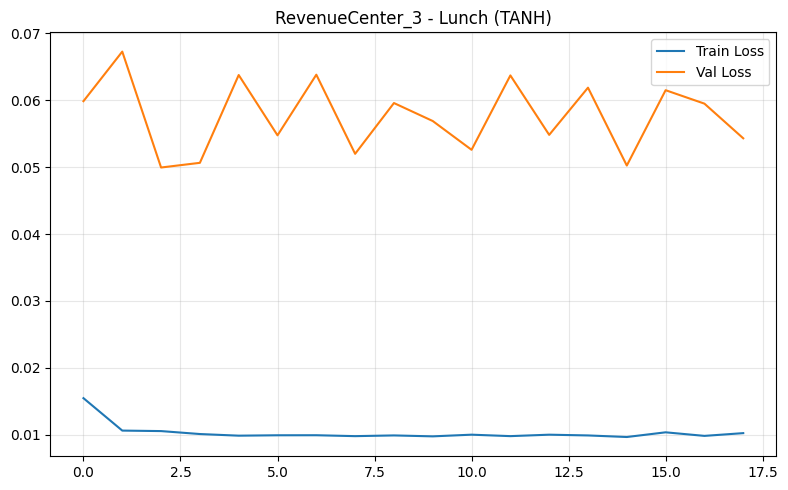

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


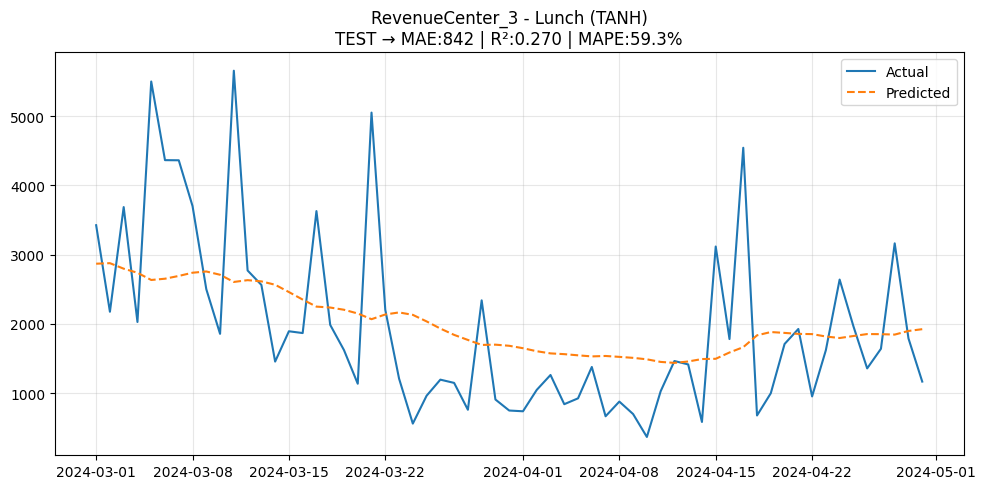

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0335 - val_loss: 0.0377
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0104 - val_loss: 0.0551
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0105 - val_loss: 0.0352
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0105 - val_loss: 0.0548
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0112 - val_loss: 0.0423
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0095 - val_loss: 0.0487
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0101 - val_loss: 0.0685
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0127 - val_loss: 0.0318
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0106 - val_loss: 0.0340
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0106 - val_loss: 0.0428
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0093 - val_loss: 0.0415
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

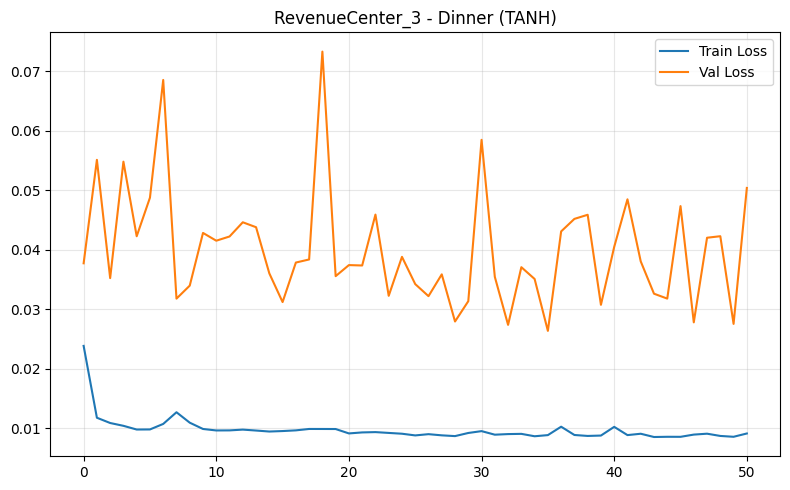

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


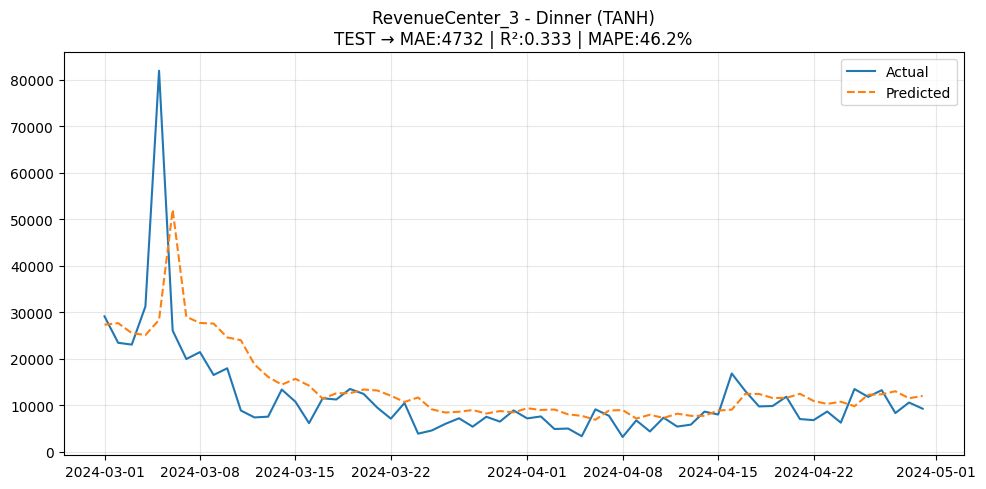

Saved: /content/RevenueCenter_3

Processing: RevenueCenter_9


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0132 - val_loss: 0.0806
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0097 - val_loss: 0.0918
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0089 - val_loss: 0.0781
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0091 - val_loss: 0.0701
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0074 - val_loss: 0.0754
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0086 - val_loss: 0.0677
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0086 - val_loss: 0.0616
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0078 - val_loss: 0.0713
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0086 - val_loss: 0.0740
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0086 - val_loss: 0.0759
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0080 - val_loss: 0.0650
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

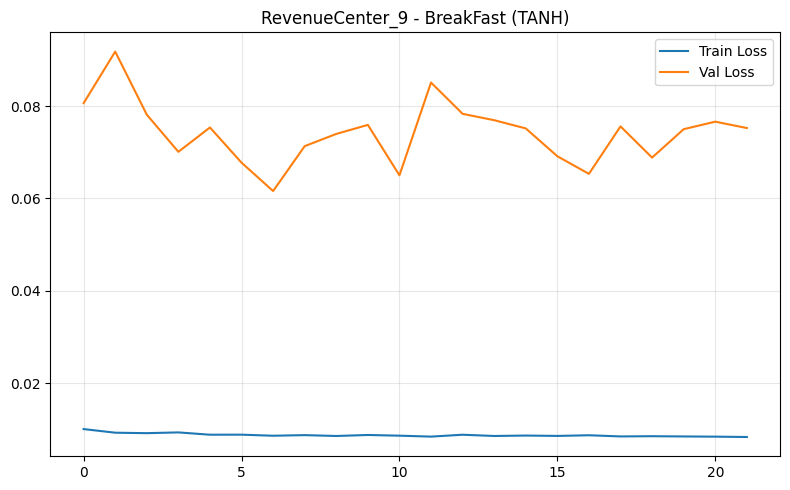

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


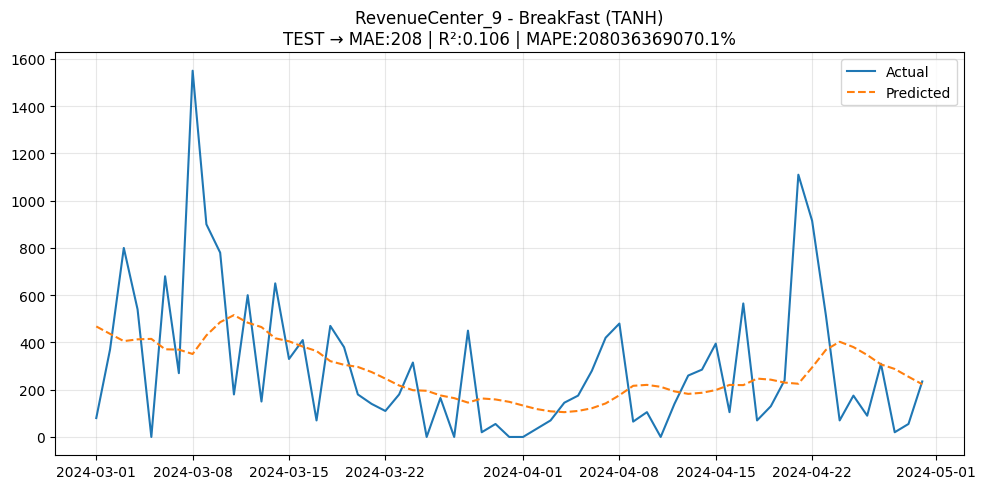

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0619 - val_loss: 0.0479
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0332 - val_loss: 0.0507
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0328 - val_loss: 0.0486
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0304 - val_loss: 0.0517
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0281 - val_loss: 0.0465
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0344 - val_loss: 0.0501
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0356 - val_loss: 0.0460
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0325 - val_loss: 0.0492
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0333 - val_loss: 0.0471
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0290 - val_loss: 0.0460
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0291 - val_loss: 0.0473
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

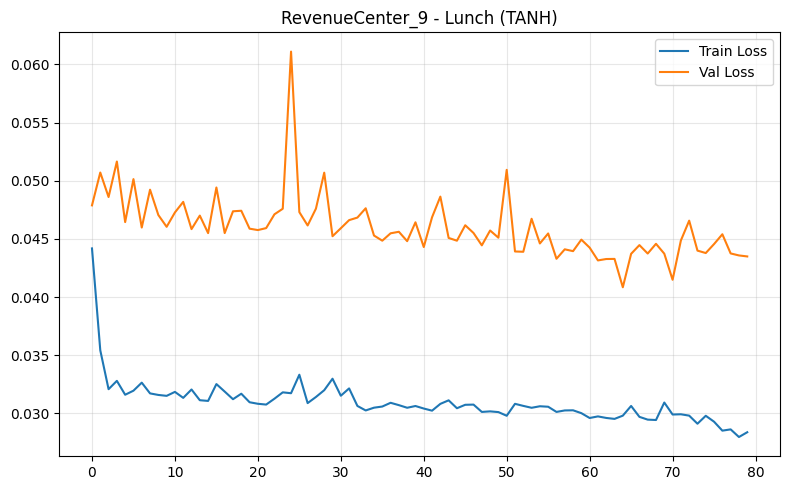

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


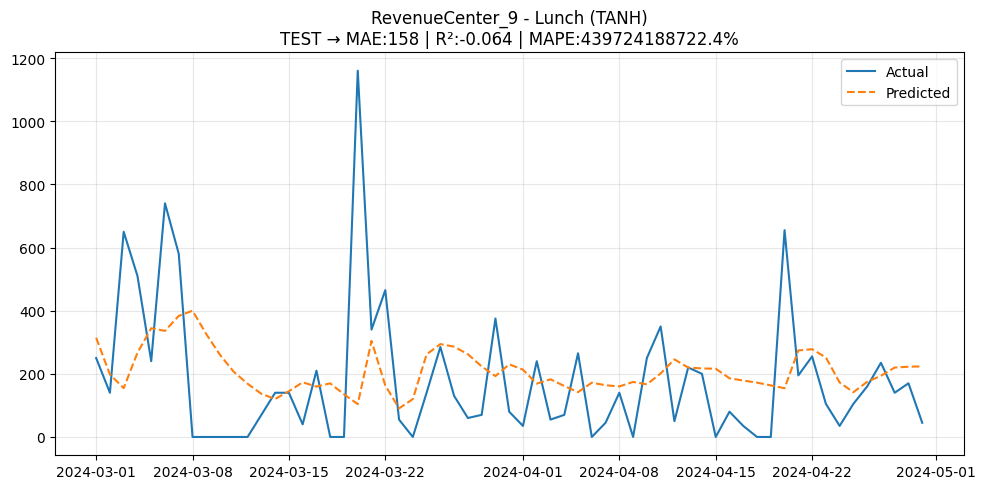

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0241 - val_loss: 0.0136
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0261 - val_loss: 0.0140
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0193 - val_loss: 0.0151
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0248 - val_loss: 0.0138
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0237 - val_loss: 0.0149
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0269 - val_loss: 0.0141
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0233 - val_loss: 0.0150
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0223 - val_loss: 0.0150
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0185 - val_loss: 0.0155
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0175 - val_loss: 0.0152
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0181 - val_loss: 0.0158
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

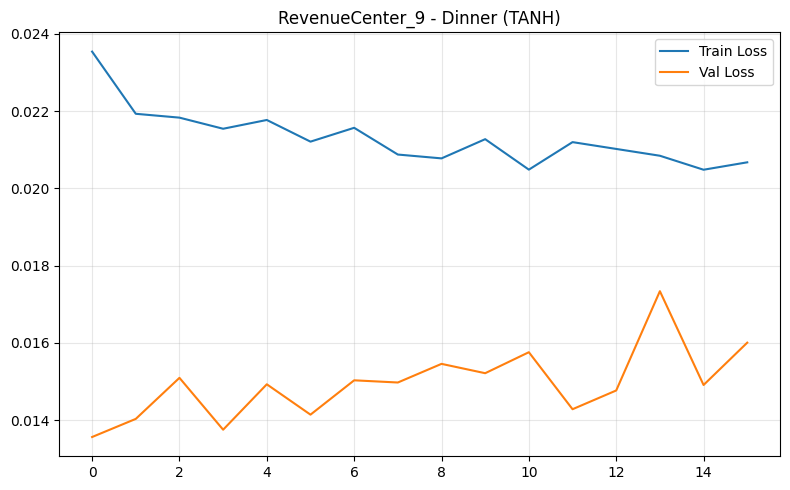

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


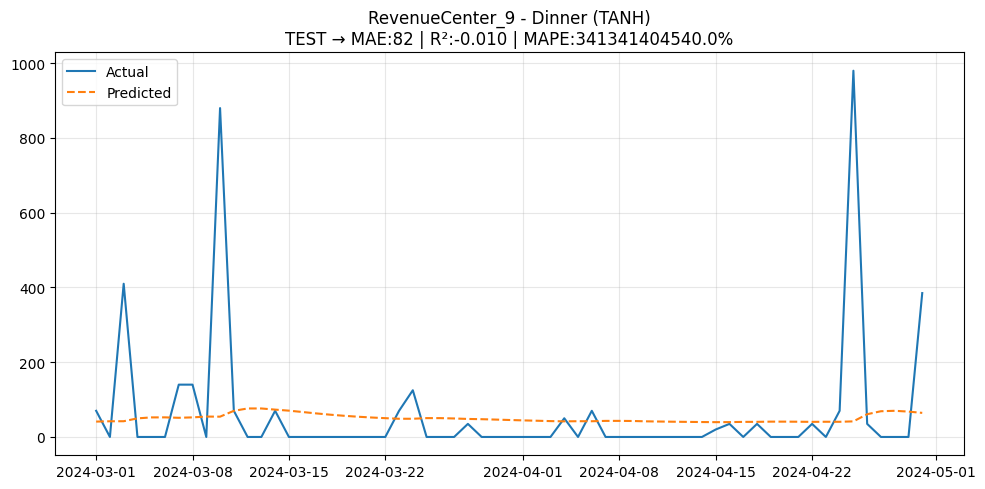

Saved: /content/RevenueCenter_9

ALL CENTERS COMPLETED — TANH MODEL


In [19]:
for file in files:

    center_name = os.path.basename(file).replace(".xlsx", "")
    print("\nProcessing:", center_name)

    center_path = os.path.join(output_folder, center_name)
    os.makedirs(center_path, exist_ok=True)

    df = pd.read_excel(file)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    split_date = df["Date"].max() - pd.DateOffset(months=2)
    meals = ["BreakFast", "Lunch", "Dinner"]

    for meal in meals:

        temp_df = df[["Date", meal]].copy()
        temp_df.rename(columns={meal: "y"}, inplace=True)

        train_df = temp_df[temp_df["Date"] <= split_date]
        test_df  = temp_df[temp_df["Date"] > split_date]

        if train_df["y"].nunique() <= 1:
            print(f"Skipping {center_name} - {meal} (constant values)")
            continue

        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_df[["y"]])
        test_scaled  = scaler.transform(test_df[["y"]])

        WINDOW = 30
        X_train, y_train = create_sequences(train_scaled, WINDOW)
        combined = np.vstack([train_scaled[-WINDOW:], test_scaled])
        X_test, y_test = create_sequences(combined, WINDOW)

        X_train = X_train.reshape(-1, WINDOW, 1)
        X_test  = X_test.reshape(-1, WINDOW, 1)

        # =========================
        # MODEL — TANH
        # =========================
        model = Sequential([

            LSTM(
                512,
                activation="tanh",
                return_sequences=True,
                input_shape=(WINDOW, 1)
            ),

            LSTM(
                256,
                activation="tanh",
                return_sequences=False
            ),

            Dense(32, activation="relu"),
            Dense(1)
        ])

        model.compile(optimizer="adam", loss="mse")

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            epochs=200,
            batch_size=32,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=1
        )

        # =========================
        # LOSS PLOT
        # =========================
        plt.figure(figsize=(8,5))
        plt.plot(history.history["loss"], label="Train Loss")
        plt.plot(history.history["val_loss"], label="Val Loss")
        plt.title(f"{center_name} - {meal} (TANH)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_loss_tanh.png"), dpi=300)
        plt.show()
        plt.close()

        # =========================
        # PREDICTIONS
        # =========================
        y_train_pred = scaler.inverse_transform(model.predict(X_train))
        y_test_pred  = scaler.inverse_transform(model.predict(X_test))
        y_train_true = scaler.inverse_transform(y_train.reshape(-1,1))
        y_test_true  = scaler.inverse_transform(y_test.reshape(-1,1))

        train_mae  = mean_absolute_error(y_train_true, y_train_pred)
        train_r2   = r2_score(y_train_true, y_train_pred)
        train_mape = mape(y_train_true, y_train_pred)

        test_mae  = mean_absolute_error(y_test_true, y_test_pred)
        test_r2   = r2_score(y_test_true, y_test_pred)
        test_mape = mape(y_test_true, y_test_pred)

        plt.figure(figsize=(10,5))
        plt.plot(test_df["Date"], y_test_true, label="Actual")
        plt.plot(test_df["Date"], y_test_pred, "--", label="Predicted")
        plt.title(
            f"{center_name} - {meal} (TANH)\n"
            f"TEST → MAE:{test_mae:.0f} | R²:{test_r2:.3f} | MAPE:{test_mape:.1f}%"
        )
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_pred_tanh.png"), dpi=300)
        plt.show()
        plt.close()

    print("Saved:", center_path)

print("\nALL CENTERS COMPLETED — TANH MODEL")

In [ ]:
y_min = y_train.min()
y_max = y_train.max()

print("Target range:", y_min, "to", y_max)
print("Range width:", y_max - y_min)

Target range: 0.0 to 37870.0
Range width: 37870.0
